# Lab 6 — Excel Group Activity

**Day 01 · Data Science Introduction · Cisco AI/ML Training**

---

## Goals

1. Complete a **group Excel analysis** on `team_sales.csv` (pivot, totals, chart).
2. Reproduce the same results in **pandas** (verification, not a separate "checkpoint file").
3. Compare **total Q2** vs **% growth** rankings by region.
4. Present one slide: *Which region won Q2? Which region improved fastest?*

> **Quick check:** **100** teams · **4** regions · total Q2 **100276** · growth teams **58** · top region **West**

**Workflow:** Excel first (group) → this notebook to verify.

## Why this matters

Most stakeholders still live in **Excel**. Data scientists must translate between pivot tables and pandas — and spot when totals and growth rates tell **different stories**.

## Excel workflow (mirror in this notebook)

| Step | Excel | pandas equivalent |
|------|-------|-------------------|
| 1 | Open CSV | `read_csv` |
| 2 | Insert → PivotTable | `pivot_table` / `groupby` |
| 3 | Sum Q1 & Q2 by region | `.sum()` |
| 4 | Count growth teams | `(q2 > q1).sum()` |
| 5 | Chart | `matplotlib` bar chart |

---

## 1. Load team sales

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# cisco-output-ready
print("Imports loaded.")


Imports loaded.


**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif GH_ROOT.name == "01-data-science-introduction":
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "data" / "team-sales" / "team_sales.csv").is_file():
            GH_ROOT = parent
            break

TEAM_SALES_CSV = GH_ROOT / "data" / "team-sales" / "team_sales.csv"

import json

# cisco-output-ready
print(f"Setup OK — repo root: {GH_ROOT}")


Setup OK — repo root: C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH


**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [3]:
LAB_PROFILE = json.loads(
    (GH_ROOT / "data" / "team-sales" / "lab_profile.json").read_text(encoding="utf-8")
)
OUTLIER_TEAM = LAB_PROFILE["outlier_team_id"]
VOL_REGION = LAB_PROFILE["compare_region_volume"]
GROWTH_REGION = LAB_PROFILE["compare_region_growth"]
df = pd.read_csv(TEAM_SALES_CSV)

print(f"teams: {df['team'].nunique()}")
print(f"regions: {df['region'].nunique()}")
display(df)

# cisco-debug-summary
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
print("dtypes:", df.dtypes.to_dict())

teams: 100
regions: 4


,team,team_name,region,state,product_line,sub_category,segment,q1_sales,q2_sales,q1_units,q2_units
0,TS001,Chicago - Chairs,Central,Illinois,Furniture,Chairs,Home Office,934,1252,7,15
1,TS002,Chicago - Chairs,Central,Illinois,Furniture,Chairs,Consumer,528,859,5,7
2,TS003,Chicago - Furnishings,Central,Illinois,Furniture,Furnishings,Consumer,164,542,7,29
3,TS004,Chicago - Machines,Central,Illinois,Technology,Machines,Home Office,785,1008,4,3
4,TS005,Chicago - Paper,Central,Illinois,Office Supplies,Paper,Home Office,560,367,16,18
...,...,...,...,...,...,...,...,...,...,...,...
95,TS096,Seattle - Paper,West,Washington,Office Supplies,Paper,Corporate,242,495,7,16
96,TS097,Seattle - Storage,West,Washington,Office Supplies,Storage,Consumer,359,659,10,6
97,TS098,Seattle - Storage,West,Washington,Office Supplies,Storage,Home Office,649,212,8,10
98,TS099,Seattle - Tables,West,Washington,Furniture,Tables,Corporate,4287,1769,10,10


Loaded 100 rows x 11 columns
dtypes: {'team': dtype('O'), 'team_name': dtype('O'), 'region': dtype('O'), 'state': dtype('O'), 'product_line': dtype('O'), 'sub_category': dtype('O'), 'segment': dtype('O'), 'q1_sales': dtype('int64'), 'q2_sales': dtype('int64'), 'q1_units': dtype('int64'), 'q2_units': dtype('int64')}


---

## 2. Pivot — Q1 vs Q2 by region (Excel PivotTable)

In [4]:
pivot = df.pivot_table(
    index="region", values=["q1_sales", "q2_sales"], aggfunc="sum"
).astype(int)
pivot["growth_units"] = pivot["q2_sales"] - pivot["q1_sales"]
pivot["growth_rate"] = (pivot["q2_sales"] - pivot["q1_sales"]) / pivot["q1_sales"]
display(pivot.round(3))

print("Rank by Q2 total:", pivot["q2_sales"].sort_values(ascending=False).index.tolist())
print("Rank by % growth:", pivot["growth_rate"].sort_values(ascending=False).index.tolist())


,q1_sales,q2_sales,growth_units,growth_rate
region,,,,
Central,15111,19696,4585,0.303
East,26263,32226,5963,0.227
South,1321,2988,1667,1.262
West,46476,45366,-1110,-0.024


Rank by Q2 total: ['West', 'East', 'Central', 'South']
Rank by % growth: ['South', 'Central', 'East', 'West']


### 2b. `groupby` equivalent (same numbers)

In [5]:
regional = df.groupby("region").agg(
    q1_sales=("q1_sales", "sum"),
    q2_sales=("q2_sales", "sum"),
).astype(int)
regional["growth"] = regional["q2_sales"] - regional["q1_sales"]
display(regional)


,q1_sales,q2_sales,growth
region,,,
Central,15111,19696,4585
East,26263,32226,5963
South,1321,2988,1667
West,46476,45366,-1110


---

## 3. Growth count and top region

In [6]:
teams_with_growth = int((df["q2_sales"] > df["q1_sales"]).sum())
total_q2 = int(df["q2_sales"].sum())
top_region = regional["q2_sales"].idxmax()

print(f"Teams with Q2 > Q1: {teams_with_growth}")
print(f"Total Q2 sales:     {total_q2}")
print(f"Top region (Q2 $):  {top_region}")


Teams with Q2 > Q1: 58
Total Q2 sales:     100276
Top region (Q2 $):  West


### 3b. Team-level growth table (for Excel conditional formatting)

In [7]:
team_view = df.copy()
team_view["grew"] = team_view["q2_sales"] > team_view["q1_sales"]
team_view["delta"] = team_view["q2_sales"] - team_view["q1_sales"]
display(team_view.sort_values("delta", ascending=False))
print(f"Declining teams: {(~team_view['grew']).sum()}")


,team,team_name,region,state,product_line,sub_category,segment,q1_sales,q2_sales,q1_units,q2_units,grew,delta
28,TS029,New York City - Binders,East,New York,Office Supplies,Binders,Consumer,654,5308,34,88,True,4654
93,TS094,Seattle - Binders,West,Washington,Office Supplies,Binders,Consumer,97,3692,5,42,True,3595
88,TS089,San Francisco - Phones,West,California,Technology,Phones,Consumer,1102,4689,11,34,True,3587
76,TS077,Los Angeles - Phones,West,California,Technology,Phones,Consumer,1376,3575,15,37,True,2199
71,TS072,Los Angeles - Machines,West,California,Technology,Machines,Consumer,1920,3892,3,16,True,1972
...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,TS099,Seattle - Tables,West,Washington,Furniture,Tables,Corporate,4287,1769,10,10,False,-2518
84,TS085,San Francisco - Binders,West,California,Office Supplies,Binders,Consumer,2904,345,28,25,False,-2559
42,TS043,New York City - Tables,East,New York,Furniture,Tables,Corporate,3579,385,17,2,False,-3194
75,TS076,Los Angeles - Phones,West,California,Technology,Phones,Home Office,5158,544,17,10,False,-4614


Declining teams: 42


---

## 4. Charts

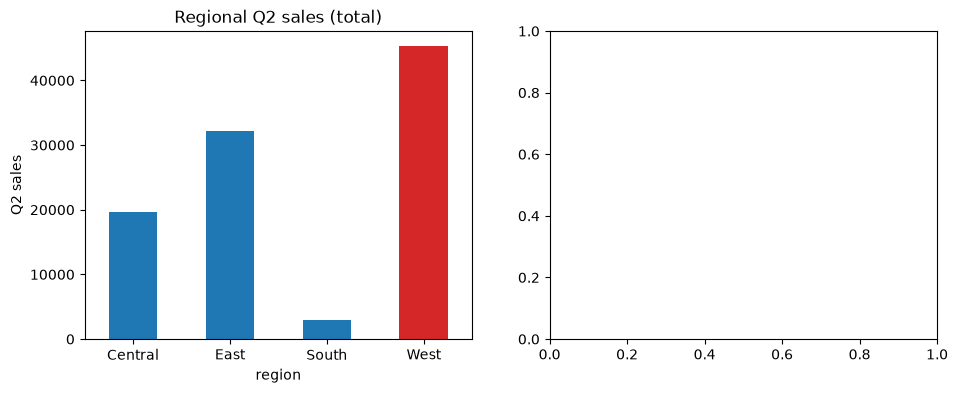

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ["#d62728" if r == top_region else "#1f77b4" for r in regional.index]
regional["q2_sales"].plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Regional Q2 sales (total)")
axes[0].set_ylabel("Q2 sales")
axes[0].tick_params(axis="x", rotation=0)

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [9]:
pivot[["q1_sales", "q2_sales"]].plot(kind="bar", ax=axes[1], width=0.8)
axes[1].set_title("Q1 vs Q2 by region")
axes[1].set_ylabel("Sales")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

### 4b. Growth rate chart — the "second story"

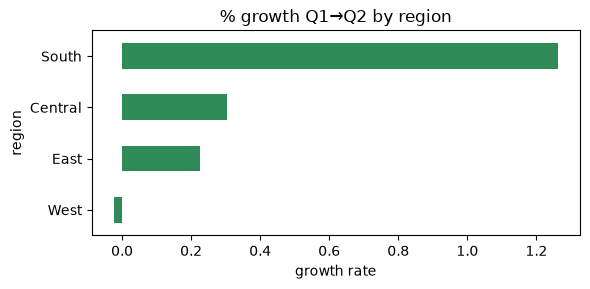

West wins total Q2 but not highest % growth among major regions — discuss in your presentation.


In [10]:
pivot["growth_rate"].sort_values().plot(kind="barh", figsize=(6, 3), color="seagreen")
plt.title("% growth Q1→Q2 by region")
plt.xlabel("growth rate")
plt.tight_layout()
plt.show()
print("West wins total Q2 but not highest % growth among major regions — discuss in your presentation.")


### 4c. Excel step-by-step (do this in your group first)

1. Open `team_sales.csv` in Excel.
2. **Insert → PivotTable** → rows = `region`, values = Sum of `q1_sales`, Sum of `q2_sales`.
3. Add helper column `Grew` = `IF(q2>q1,1,0)` → `SUMIF` by region.
4. Insert **column chart** of regional Q2 totals.
5. Screenshot for your slide — then verify below.

### 4d. SUMIF-style verification in pandas

In [11]:
for reg in sorted(df["region"].unique()):
    sub = df.loc[df["region"] == reg]
    print(
        f"{reg:6s}  Q1={sub['q1_sales'].sum():4d}  Q2={sub['q2_sales'].sum():4d}  "
        f"growth_teams={(sub['q2_sales'] > sub['q1_sales']).sum()}/5"
    )


Central  Q1=15111  Q2=19696  growth_teams=16/5
East    Q1=26263  Q2=32226  growth_teams=19/5
South   Q1=1321  Q2=2988  growth_teams=4/5
West    Q1=46476  Q2=45366  growth_teams=19/5


### 4e. West vs Central — prepare your talking point

In [12]:
story = pd.DataFrame({
    "region": ["West", "Central"],
    "q2_total": [regional.loc["West", "q2_sales"], regional.loc["Central", "q2_sales"]],
    "pct_growth": [pivot.loc["West", "growth_rate"], pivot.loc["Central", "growth_rate"]],
}).round(3)
display(story)
print(f"{VOL_REGION}: highest Q2 total. {GROWTH_REGION}: strongest % growth among major regions. Both can be true.")


,region,q2_total,pct_growth
0,West,45366,-0.024
1,Central,19696,0.303


West: highest Q2 total. Central: strongest % growth among major regions. Both can be true.


### 4f. Copy table to Excel (manual)

In [13]:
print("Copy this table into Excel for chart formatting:")
display(pivot.round(3))


Copy this table into Excel for chart formatting:


,q1_sales,q2_sales,growth_units,growth_rate
region,,,,
Central,15111,19696,4585,0.303
East,26263,32226,5963,0.227
South,1321,2988,1667,1.262
West,46476,45366,-1110,-0.024


---

## 5. Verify your Excel answers

In [14]:
assert len(df) == LAB_PROFILE["rows"]
assert df["region"].nunique() == LAB_PROFILE["regions"]
assert total_q2 == LAB_PROFILE["total_q2_sales"]
assert teams_with_growth == LAB_PROFILE["growth_teams_count"]
assert top_region == VOL_REGION

for region_name, totals in LAB_PROFILE["regional_totals"].items():
    row = regional.loc[region_name]
    assert int(row["q1_sales"]) == totals["q1_sales"]
    assert int(row["q2_sales"]) == totals["q2_sales"]
    assert int(row["growth"]) == totals["q2_sales"] - totals["q1_sales"]

print("✓ Excel answers match Python verification")


✓ Excel answers match Python verification


## Group presentation prompt

Prepare **one slide** with:
- Regional Q2 totals (bar chart screenshot from Excel or this notebook)
- One sentence: *West had highest Q2 total, but Central had the strongest % growth among major regions*
- Which CRISP-DM phase was this analysis? (**Evaluation** / communication)

## Reflection questions

1. When would leadership care more about **% growth** than **absolute Q2**?
2. What would you do differently with 200 teams instead of 20?
3. How does this activity connect to Day 2 Zomato EDA?